In [13]:
pip install pandas numpy matplotlib


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


# Aula 03 — NumPy com a base_rh

**Semana 05 · Dia 03 · SENAI — Visualização de Dados e Business Intelligence**

Nas duas primeiras aulas você aprendeu a trabalhar com pandas. Hoje vamos um nível abaixo: o **NumPy**, a biblioteca que o próprio pandas usa por dentro.

A boa notícia: você já conhece os dados. Vamos continuar com a `base_rh.xlsx` — os mesmos 1.000 funcionários — mas agora vamos manipular os dados como **arrays NumPy puro**, entendendo o que acontece por baixo dos panos quando você usa o pandas.

**Ao final desta aula você vai saber:**

- Extrair arrays NumPy de um DataFrame pandas
- Criar e inspecionar arrays (shape, ndim, dtype, size)
- Selecionar dados com slicing (1D e 2D)
- Fazer cálculos em arrays inteiros sem escrever um único loop
- Usar broadcasting para aplicar operações por grupo
- Usar `np.where()` e `np.select()` para classificar dados
- Criar histogramas com bins controlados via NumPy

## Bloco 0 — Setup

Mesma célula de sempre para carregar a `base_rh`, mas agora importamos também o **NumPy** com o apelido `np`.

Depois de carregar o DataFrame, vamos **extrair colunas numéricas como arrays NumPy** usando `.to_numpy()`. Isso é exatamente o que o pandas faz internamente quando você chama `.mean()`, `.sum()` etc.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = (
    "https://raw.githubusercontent.com/"
    "cfneves/turma-visualizacao-de-dados/"
    "master/aulas/semana_04/bases/base_rh.xlsx"
)

df = pd.read_excel(URL)

df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"
)

print(f"Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(df.dtypes)

Dataset: 1000 linhas x 10 colunas
ID_Funcionario             int64
Nome                         str
Departamento                 str
Cargo                        str
Salario                  float64
Data_Admissao     datetime64[us]
Genero                       str
Idade                      int64
Estado_Civil                 str
Status                       str
dtype: object


---
## Bloco 1 — Arrays e Dimensões

### pandas por dentro é NumPy

Toda coluna numérica de um DataFrame pandas é armazenada internamente como um **array NumPy**. Quando você chama `df["Salario"].mean()`, o pandas simplesmente delega o cálculo para o NumPy.

Para ver isso, usamos `.to_numpy()` — que "expõe" o array que já estava lá:

```python
df["Salario"].to_numpy()   # retorna numpy.ndarray
```

Entender arrays NumPy é entender o que o pandas faz por baixo dos panos.

### Exemplo 01 — Extraindo arrays de um DataFrame

`.to_numpy()` converte uma coluna pandas em array NumPy 1D. Para múltiplas colunas, usamos `np.column_stack()` para empilhar arrays 1D lado a lado e formar um array 2D.

| Função/método | O que faz |
|---|---|
| `df["col"].to_numpy()` | Coluna → array 1D |
| `np.column_stack([a, b, c])` | Empilha arrays 1D em colunas → array 2D |
| `arr.shape` | Dimensões do array `(linhas, colunas)` |
| `arr.ndim` | Número de dimensões |
| `arr.dtype` | Tipo de dado |
| `arr.size` | Total de elementos |

In [15]:
# ── Extraindo arrays 1D das colunas numéricas ─────────────────────────────
salarios = df["Salario"].to_numpy()
idades   = df["Idade"].to_numpy()
ids      = df["ID_Funcionario"].to_numpy()

print("=== salarios (1D) ===")
print(f"  type  : {type(salarios)}")
print(f"  shape : {salarios.shape}")
print(f"  ndim  : {salarios.ndim}")
print(f"  dtype : {salarios.dtype}")
print(f"  size  : {salarios.size}")
print(f"  5 primeiros: {salarios[:5]}")

# ── Criando um array 2D com múltiplas colunas ──────────────────────────────
dados_numericos = np.column_stack([ids, idades, salarios])

print(f"\n=== dados_numericos (2D) ===")
print(f"  shape : {dados_numericos.shape}   → {dados_numericos.shape[0]} funcionários · 3 colunas")
print(f"  ndim  : {dados_numericos.ndim}")
print(f"  dtype : {dados_numericos.dtype}")
print(f"\nPrimeiras 3 linhas:")
print(dados_numericos[:3])

=== salarios (1D) ===
  type  : <class 'numpy.ndarray'>
  shape : (1000,)
  ndim  : 1
  dtype : float64
  size  : 1000
  5 primeiros: [ 9088.34  8155.98 14027.93  6647.97  8730.19]

=== dados_numericos (2D) ===
  shape : (1000, 3)   → 1000 funcionários · 3 colunas
  ndim  : 2
  dtype : float64

Primeiras 3 linhas:
[[1.000000e+00 4.300000e+01 9.088340e+03]
 [2.000000e+00 5.900000e+01 8.155980e+03]
 [3.000000e+00 2.700000e+01 1.402793e+04]]


### Exemplo 02 — Comparando: pandas Series vs array NumPy

Visualmente o resultado de `df["Salario"]` e `salarios` parece igual, mas eles são objetos diferentes com comportamentos distintos.

| | pandas Series | numpy ndarray |
|---|---|---|
| Índice | Sim (0, 1, 2...) | Não — só posição |
| Rótulos | Sim (nome da coluna) | Não |
| Métodos | `.value_counts()`, `.str`, `.dt`... | Operações matemáticas puras |
| Uso típico | Análise e exploração | Cálculo numérico de alta performance |

> **Regra prática:** use pandas para explorar e filtrar dados; use NumPy quando precisar de cálculo numérico intenso, normalização ou operações matriciais.

In [16]:
# Pandas Series
serie_salario = df["Salario"]
print("pandas Series:")
print(f"  type  : {type(serie_salario)}")
print(f"  index : {serie_salario.index[:5].tolist()} ...")
print(f"  values: {serie_salario.values[:5]}")  # .values também retorna o array

print()

# NumPy array
print("numpy ndarray:")
print(f"  type  : {type(salarios)}")
print(f"  Não tem índice — só posição")
print(f"  valores: {salarios[:5]}")

# São os mesmos números — só a embalagem muda
print(f"\nOs dados são idênticos? {np.array_equal(serie_salario.values, salarios)}")

pandas Series:
  type  : <class 'pandas.Series'>
  index : [0, 1, 2, 3, 4] ...
  values: [ 9088.34  8155.98 14027.93  6647.97  8730.19]

numpy ndarray:
  type  : <class 'numpy.ndarray'>
  Não tem índice — só posição
  valores: [ 9088.34  8155.98 14027.93  6647.97  8730.19]

Os dados são idênticos? True


---
## Bloco 2 — Slicing: selecionando partes do array

Slicing em NumPy usa a mesma sintaxe de listas Python, mas com suporte a múltiplas dimensões separadas por vírgula:

```python
arr[linhas, colunas]
```

O `:` significa "tudo" naquela dimensão — exatamente como você já viu no `df.iloc[linhas, colunas]` do pandas. Não é coincidência: o pandas copiou essa sintaxe do NumPy.

### Exemplo 03 — Slicing 1D nos salários

| Sintaxe | O que seleciona |
|---|---|
| `arr[0]` | Primeiro elemento |
| `arr[-1]` | Último elemento |
| `arr[2:5]` | Posições 2, 3 e 4 |
| `arr[:10]` | Primeiros 10 |
| `arr[-10:]` | Últimos 10 |
| `arr[::50]` | Um a cada 50 (amostra) |

In [17]:
print(f"Primeiro salário  : R$ {salarios[0]:,.2f}")
print(f"Último salário    : R$ {salarios[-1]:,.2f}")
print(f"Funcionários 1-5  : {salarios[:5]}")
print(f"Últimos 5         : {salarios[-5:]}")

# Amostragem: 1 a cada 100 funcionários
amostra = salarios[::100]
print(f"\nAmostra (1 a cada 100 funcionários):")
print(amostra)

# Boolean indexing: salários acima de 12.000
altos = salarios[salarios > 12_000]
print(f"\nFuncionários com salário > R$ 12.000: {len(altos)}")
print(f"Menor salário do grupo: R$ {altos.min():,.2f}")
print(f"Maior salário do grupo: R$ {altos.max():,.2f}")

Primeiro salário  : R$ 9,088.34
Último salário    : R$ 12,549.72
Funcionários 1-5  : [ 9088.34  8155.98 14027.93  6647.97  8730.19]
Últimos 5         : [11389.03 14060.42  2348.73  9430.62 12549.72]

Amostra (1 a cada 100 funcionários):
[ 9088.34  3301.95 13768.79  8977.74  8289.2  11183.81  2645.77  6764.42
  7492.24  4618.91]

Funcionários com salário > R$ 12.000: 220
Menor salário do grupo: R$ 12,004.09
Maior salário do grupo: R$ 14,954.51


### Exemplo 04 — Slicing 2D: linhas e colunas

No array 2D `dados_numericos` criado antes, temos:
- **Coluna 0** = ID_Funcionario
- **Coluna 1** = Idade
- **Coluna 2** = Salario

```python
dados_numericos[0, :]    # linha 0 → funcionário 1, todas as colunas
dados_numericos[:, 2]    # coluna 2 → salários de todos os funcionários
dados_numericos[0:5, 1:] # linhas 0-4, colunas 1 e 2 (Idade e Salario)
```

In [18]:
print("=== Slicing 2D: dados_numericos (1000, 3) ===\n")

# Linha 0 → primeiro funcionário
print("Funcionário 1 (linha 0 — todas as colunas):")
print(f"  ID={dados_numericos[0, 0]:.0f} · Idade={dados_numericos[0, 1]:.0f} · Salário=R$ {dados_numericos[0, 2]:,.2f}")

# Coluna 2 → todos os salários (equivalente a salarios[:])
sal_col2 = dados_numericos[:, 2]
print(f"\nColuna 2 (Salário) extraída via slicing 2D:")
print(f"  shape: {sal_col2.shape} · igual a salarios[:]: {np.array_equal(sal_col2, salarios)}")

# Sub-matriz: funcionários 50-54, colunas Idade e Salário
print("\nFuncionários 51-55 · Idade e Salário:")
submatriz = dados_numericos[50:55, 1:]
print(submatriz)

# Funcionários de maior salário: últimos 5 após ordenar
indices_ordenados = np.argsort(salarios)           # índices que ordenariam o array
top5_idx = indices_ordenados[-5:][::-1]            # últimos 5, do maior para menor
print("\nTop 5 salários (via np.argsort):")
for idx in top5_idx:
    print(f"  Funcionário pos {idx} → R$ {salarios[idx]:,.2f}")

=== Slicing 2D: dados_numericos (1000, 3) ===

Funcionário 1 (linha 0 — todas as colunas):
  ID=1 · Idade=43 · Salário=R$ 9,088.34

Coluna 2 (Salário) extraída via slicing 2D:
  shape: (1000,) · igual a salarios[:]: True

Funcionários 51-55 · Idade e Salário:
[[   30.    6506.85]
 [   27.   10022.05]
 [   52.   12624.23]
 [   18.    4529.45]
 [   56.    6495.75]]

Top 5 salários (via np.argsort):
  Funcionário pos 675 → R$ 14,954.51
  Funcionário pos 801 → R$ 14,951.53
  Funcionário pos 104 → R$ 14,948.18
  Funcionário pos 982 → R$ 14,942.48
  Funcionário pos 604 → R$ 14,942.39


---
## Bloco 3 — Operações Vetorizadas: cálculos sem loops

**Vetorização** significa aplicar uma operação a **todos os elementos de uma vez**, sem escrever `for`. O NumPy executa essa lógica em código C compilado — muito mais rápido que um loop Python.

Comparação real:

```python
# Jeito lento — loop Python
resultado = []
for s in salarios:
    resultado.append(s * 1.10)

# Jeito NumPy — vetorizado (mesmo resultado, ~100x mais rápido)
resultado = salarios * 1.10
```

### Exemplo 05 — Aritmética aplicada aos salários

Quando você opera um array com um escalar (número único), o NumPy aplica a operação a **cada elemento** automaticamente.

Quando opera dois arrays de mesmo shape, a operação é **elemento por elemento**: `arr1[i]` opera com `arr2[i]`.

In [19]:
# ── Reajuste salarial de 8% para todos ───────────────────────────────────
salarios_reajustados = salarios * 1.08
print("Impacto de um reajuste de 8%:")
print(f"  Folha atual    : R$ {salarios.sum():>15,.2f}")
print(f"  Folha reajuste : R$ {salarios_reajustados.sum():>15,.2f}")
print(f"  Custo adicional: R$ {(salarios_reajustados - salarios).sum():>15,.2f}")

# ── INSS simplificado: 7.5% sobre salário ────────────────────────────────
inss = salarios * 0.075
salario_liquido = salarios - inss
print(f"\nDesconto INSS (7,5%):")
print(f"  Salário bruto médio  : R$ {salarios.mean():,.2f}")
print(f"  INSS médio           : R$ {inss.mean():,.2f}")
print(f"  Salário líquido médio: R$ {salario_liquido.mean():,.2f}")

# ── Operação entre dois arrays: diferença entre salário e média ───────────
media_geral = salarios.mean()
desvio_da_media = salarios - media_geral   # subtrai escalar de cada elemento

print(f"\nDesvio em relação à média (R$ {media_geral:,.2f}):")
print(f"  Maior desvio positivo: +R$ {desvio_da_media.max():,.2f}")
print(f"  Maior desvio negativo: -R$ {abs(desvio_da_media.min()):,.2f}")
print(f"  Acima da média       : {(desvio_da_media > 0).sum()} funcionários")
print(f"  Abaixo da média      : {(desvio_da_media < 0).sum()} funcionários")

Impacto de um reajuste de 8%:
  Folha atual    : R$    8,579,951.78
  Folha reajuste : R$    9,266,347.92
  Custo adicional: R$      686,396.14

Desconto INSS (7,5%):
  Salário bruto médio  : R$ 8,579.95
  INSS médio           : R$ 643.50
  Salário líquido médio: R$ 7,936.46

Desvio em relação à média (R$ 8,579.95):
  Maior desvio positivo: +R$ 6,374.56
  Maior desvio negativo: -R$ 6,579.24
  Acima da média       : 500 funcionários
  Abaixo da média      : 500 funcionários


### Exemplo 06 — Funções de agregação e o parâmetro `axis`

NumPy tem funções matemáticas otimizadas para calcular estatísticas sobre arrays inteiros ou ao longo de uma dimensão específica.

O parâmetro `axis` controla **sobre qual dimensão** agregar:

```
array 2D (1000, 3)   →  ID · Idade · Salário

axis=0   →  agrega sobre as linhas   → resultado: (3,)  — uma stat por coluna
axis=1   →  agrega sobre as colunas  → resultado: (1000,) — uma stat por linha
```

In [20]:
# ── Estatísticas sobre o array 1D de salários ────────────────────────────
print("=== Estatísticas dos Salários ===")
print(f"  np.mean   : R$ {np.mean(salarios):>10,.2f}")
print(f"  np.median : R$ {np.median(salarios):>10,.2f}")
print(f"  np.std    : R$ {np.std(salarios):>10,.2f}")
print(f"  np.min    : R$ {np.min(salarios):>10,.2f}")
print(f"  np.max    : R$ {np.max(salarios):>10,.2f}")
print(f"  np.sum    : R$ {np.sum(salarios):>10,.2f}  (folha total)")



=== Estatísticas dos Salários ===
  np.mean   : R$   8,579.95
  np.median : R$   8,571.13
  np.std    : R$   3,655.54
  np.min    : R$   2,000.71
  np.max    : R$  14,954.51
  np.sum    : R$ 8,579,951.78  (folha total)

Percentis:
  25% dos funcionários ganham até R$ 5,564.55
  50% dos funcionários ganham até R$ 8,571.13  (mediana)
  75% dos funcionários ganham até R$ 11,554.63

Média de cada coluna do array 2D (axis=0):
  ID      : 500.50
  Idade   : 41.40
  Salário : 8,579.95


In [23]:
# ── Percentis: divisão da distribuição em partes ─────────────────────────
p25, p50, p75 = np.percentile(salarios, [25, 50, 75])
print(f"\nPercentis:")
print(f"  25% dos funcionários ganham até R$ {p25:,.2f}")
print(f"  50% dos funcionários ganham até R$ {p50:,.2f}  (mediana)")
print(f"  75% dos funcionários ganham até R$ {p75:,.2f}")



Percentis:
  25% dos funcionários ganham até R$ 5,564.55
  50% dos funcionários ganham até R$ 8,571.13  (mediana)
  75% dos funcionários ganham até R$ 11,554.63


In [24]:
# ── axis no array 2D ─────────────────────────────────────────────────────
colunas = ["ID", "Idade", "Salário"]
medias_por_coluna = np.mean(dados_numericos, axis=0)   # uma média por coluna
print(f"\nMédia de cada coluna do array 2D (axis=0):")
for col, media in zip(colunas, medias_por_coluna):
    print(f"  {col:8s}: {media:,.2f}")


Média de cada coluna do array 2D (axis=0):
  ID      : 500.50
  Idade   : 41.40
  Salário : 8,579.95


### Exemplo 07 — Histograma com bins definidos pelo NumPy

Até agora passávamos apenas o número de bins para `plt.hist()`. Com NumPy, podemos passar um **array de limites exatos**, o que nos dá controle preciso sobre onde cada faixa começa e termina.

Isso é especialmente útil quando as faixas têm significado de negócio — como os limites das faixas salariais que criamos na Aula 01.

In [27]:
# Bins alinhados com limites de faixa salarial com significado de negócio
bins_sal = np.array([0, 4000, 8000, 12000, 16000])
print("Limites das faixas:", bins_sal)



Limites das faixas: [    0  4000  8000 12000 16000]


In [25]:
# np.histogram retorna as contagens sem plotar — útil para inspecionar
contagens, limites = np.histogram(salarios, bins=bins_sal)
rotulos = ["Até R$4k", "R$4k-8k", "R$8k-12k", "Acima R$12k"]
print("\nDistribuição pré-plotagem:")
for rot, cnt in zip(rotulos, contagens):
    print(f"  {rot:15s}: {cnt:4d} funcionários ({cnt/len(salarios)*100:.1f}%)")




Distribuição pré-plotagem:
  Até R$4k       :  132 funcionários (13.2%)
  R$4k-8k        :  320 funcionários (32.0%)
  R$8k-12k       :  328 funcionários (32.8%)
  Acima R$12k    :  220 funcionários (22.0%)


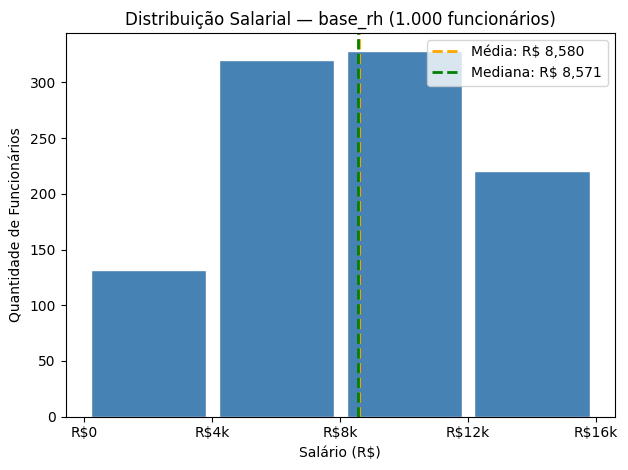

In [26]:
# Histograma com os bins definidos via NumPy
plt.hist(salarios, bins=bins_sal, color="steelblue", edgecolor="white", rwidth=0.9)
plt.axvline(np.mean(salarios),   color="orange", linestyle="--", linewidth=2,
            label=f"Média: R$ {np.mean(salarios):,.0f}")
plt.axvline(np.median(salarios), color="green",  linestyle="--", linewidth=2,
            label=f"Mediana: R$ {np.median(salarios):,.0f}")
plt.title("Distribuição Salarial — base_rh (1.000 funcionários)")
plt.xlabel("Salário (R$)")
plt.ylabel("Quantidade de Funcionários")
plt.xticks(bins_sal, [f"R${v//1000}k" if v > 0 else "R$0" for v in bins_sal])
plt.legend()
plt.tight_layout()
plt.show()

---
### O que este gráfico mostra?

Cada barra representa uma faixa salarial com limites definidos por nós (R$0–4k, R$4k–8k, R$8k–12k e acima de R$12k). A altura mostra quantos dos 1.000 funcionários estão em cada faixa. As linhas tracejadas marcam a **média** e a **mediana**.

### Por que isso importa?

- A diferença entre média e mediana revela se os salários altos estão "puxando" a média para cima — um dado crítico para diagnóstico de equidade salarial
- Definir os bins com `np.array([0, 4000, 8000, 12000, 16000])` em vez de apenas `bins=4` garante que as divisões coincidam exatamente com as faixas de negócio, tornando o gráfico diretamente comparável com outros relatórios da empresa
- `np.histogram()` (sem plotar) permite inspecionar os números antes de exibir — bom hábito para validar os dados

---
## Bloco 4 — Broadcasting: operações entre shapes diferentes

**Broadcasting** é a capacidade do NumPy de operar arrays com formas diferentes, desde que as dimensões sejam compatíveis. O caso mais comum: aplicar um valor diferente **por grupo**.

Exemplo real: cada departamento tem uma taxa de bônus diferente. Sem broadcasting, você precisaria de um loop. Com broadcasting, é uma operação só.

**Regra simplificada:** as dimensões precisam ser iguais ou uma delas precisa ser 1.

In [32]:
# ── Mapeando departamentos para índices numéricos ─────────────────────────
deptos_unicos = df["Departamento"].unique()
deptos_unicos.sort()



AttributeError: 'StringArray' object has no attribute 'sort'

In [29]:
# Cria um array de índice de departamento para cada funcionário
depto_map = {d: i for i, d in enumerate(deptos_unicos)}
depto_idx = df["Departamento"].map(depto_map).to_numpy()



In [30]:
# Reajuste específico por departamento
reajuste_pct = np.array([0.10, 0.07, 0.09, 0.12, 0.06, 0.08, 0.11])
nomes_deptos = deptos_unicos

print("Reajuste por departamento:")
for nome, pct in zip(nomes_deptos, reajuste_pct):
    print(f"  {nome:12s}: {pct*100:.0f}%")



Reajuste por departamento:
  Logística   : 10%
  TI          : 7%
  RH          : 9%
  Produção    : 12%
  Vendas      : 6%
  Financeiro  : 8%


In [31]:
# Broadcasting: reajuste_pct[depto_idx] seleciona o % correto para cada
# funcionário — sem loop!
pct_por_funcionario = reajuste_pct[depto_idx]        # shape (1000,)
salarios_reaj_depto = salarios * (1 + pct_por_funcionario)

print(f"\nImpacto do reajuste por departamento:")
for i, (nome, pct) in enumerate(zip(nomes_deptos, reajuste_pct)):
    mascara = depto_idx == i
    antes  = salarios[mascara].mean()
    depois = salarios_reaj_depto[mascara].mean()
    print(f"  {nome:12s}: R$ {antes:,.2f} → R$ {depois:,.2f}  (+R$ {depois-antes:,.2f})")


Impacto do reajuste por departamento:
  Logística   : R$ 8,881.66 → R$ 9,769.82  (+R$ 888.17)
  TI          : R$ 8,142.91 → R$ 8,712.92  (+R$ 570.00)
  RH          : R$ 8,791.58 → R$ 9,582.82  (+R$ 791.24)
  Produção    : R$ 8,968.73 → R$ 10,044.98  (+R$ 1,076.25)
  Vendas      : R$ 8,317.08 → R$ 8,816.11  (+R$ 499.03)
  Financeiro  : R$ 8,333.12 → R$ 8,999.77  (+R$ 666.65)


---
## Bloco 5 — `np.where()` e `np.select()`: classificação vetorizada

`np.where(condição, valor_se_true, valor_se_false)` é o `if/else` do NumPy: avalia a condição para **cada elemento** e retorna o valor correspondente, sem loops.

`np.select(condições, escolhas, default)` estende isso para **múltiplas condições** — mais limpo que `np.where` aninhado quando você tem 3 ou mais categorias.

### Exemplo 09 — Recriando a coluna Faixa_Salarial com NumPy

Na Aula 01 criamos a coluna `Faixa_Salarial` usando `df.loc`. Agora vamos fazer o mesmo com `np.select()` — e entender por que o pandas faz isso tão rápido internamente.

In [33]:
# ── np.where: classificação binária ─────────────────────────────────────
acima_media = np.where(salarios > salarios.mean(), "Acima", "Abaixo")
n_acima  = (acima_media == "Acima").sum()
n_abaixo = (acima_media == "Abaixo").sum()
print(f"Acima da média  : {n_acima:4d} funcionários")
print(f"Abaixo da média : {n_abaixo:4d} funcionários")

# ── np.select: quatro faixas salariais — mesmo resultado da Aula 01 ──────
condicoes = [
    salarios >  12_000,
    salarios.between(8_001, 12_000) if hasattr(salarios, "between")
        else (salarios > 8_000) & (salarios <= 12_000),
    salarios.between(4_001,  8_000) if hasattr(salarios, "between")
        else (salarios > 4_000) & (salarios <= 8_000),
]
# NumPy puro: sem método .between(), usamos comparações diretas
condicoes = [
    salarios >  12_000,
    (salarios >  8_000) & (salarios <= 12_000),
    (salarios >  4_000) & (salarios <=  8_000),
]
categorias = ["Especialista", "Senior", "Pleno"]

faixa_np = np.select(condicoes, categorias, default="Junior")

# Contagem de cada faixa
faixas, contagens = np.unique(faixa_np, return_counts=True)
print("\nFaixas salariais (via np.select):")
for f, c in zip(faixas, contagens):
    print(f"  {f:14s}: {c:4d} funcionários ({c/len(faixa_np)*100:.1f}%)")

# Adicionando ao DataFrame para usar no gráfico
df["Faixa_NP"] = faixa_np
print("\nColunas do DataFrame:", df.columns.tolist())

Acima da média  :  500 funcionários
Abaixo da média :  500 funcionários

Faixas salariais (via np.select):
  Especialista  :  220 funcionários (22.0%)
  Junior        :  132 funcionários (13.2%)
  Pleno         :  320 funcionários (32.0%)
  Senior        :  328 funcionários (32.8%)

Colunas do DataFrame: ['ID_Funcionario', 'Nome', 'Departamento', 'Cargo', 'Salario', 'Data_Admissao', 'Genero', 'Idade', 'Estado_Civil', 'Status', 'Faixa_NP']


### Exemplo 10 — Gráfico das faixas salariais criadas com NumPy

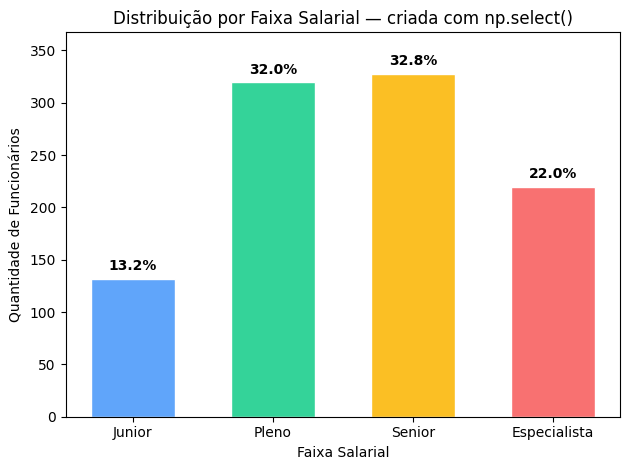

In [34]:
# Ordem lógica das faixas
ordem = ["Junior", "Pleno", "Senior", "Especialista"]
cores = ["#60a5fa", "#34d399", "#fbbf24", "#f87171"]

# Conta usando NumPy puro
contagens_ord = np.array([np.sum(faixa_np == f) for f in ordem])

plt.bar(ordem, contagens_ord, color=cores, edgecolor="white", width=0.6)

# Rótulo com % em cima de cada barra
for i, (faixa, cnt) in enumerate(zip(ordem, contagens_ord)):
    plt.text(i, cnt + 5, f"{cnt/len(faixa_np)*100:.1f}%",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("Distribuição por Faixa Salarial — criada com np.select()")
plt.xlabel("Faixa Salarial")
plt.ylabel("Quantidade de Funcionários")
plt.ylim(0, contagens_ord.max() * 1.12)
plt.tight_layout()
plt.show()

---
### O que este gráfico mostra?

Cada barra representa uma **faixa salarial** e sua altura mostra quantos funcionários pertencem a ela. Os percentuais acima de cada barra permitem comparação proporcional sem precisar calcular manualmente.

### Por que isso importa?

- A distribuição das faixas revela a **pirâmide de maturidade** da equipe: uma base larga de Juniors indica muita entrada de novos funcionários; uma pirâmide invertida (mais Especialistas) pode sinalizar custo de folha elevado
- O dado foi criado com `np.select()` — sem um único loop Python, o que significa que funcionaria igualmente rápido com 1 milhão de registros
- Comparar esse gráfico com o da Aula 01 (feito com `df.loc`) mostra que chegamos ao **mesmo resultado por dois caminhos diferentes**: pandas (alto nível) e NumPy (baixo nível)

### Exemplo 11 — Estatísticas por faixa: média, desvio e amplitude

Vamos usar NumPy puro — sem `groupby` — para calcular estatísticas de cada faixa salarial. A lógica é: **máscara booleana → seleciona o subarray → calcula a estatística**.

```python
mascara = faixa_np == "Senior"
salarios[mascara].mean()   # média só dos Sêniors
```

Faixa              N        Média      Mediana     Desvio        Mín        Máx
───────────────────────────────────────────────────────────────────────────
Junior           132 R$     2,979 R$     2,923 R$     553 R$   2,001 R$   3,997
Pleno            320 R$     6,032 R$     5,997 R$   1,144 R$   4,008 R$   7,996
Senior           328 R$     9,985 R$     9,984 R$   1,148 R$   8,002 R$  11,987
Especialista     220 R$    13,552 R$    13,610 R$     869 R$  12,004 R$  14,955


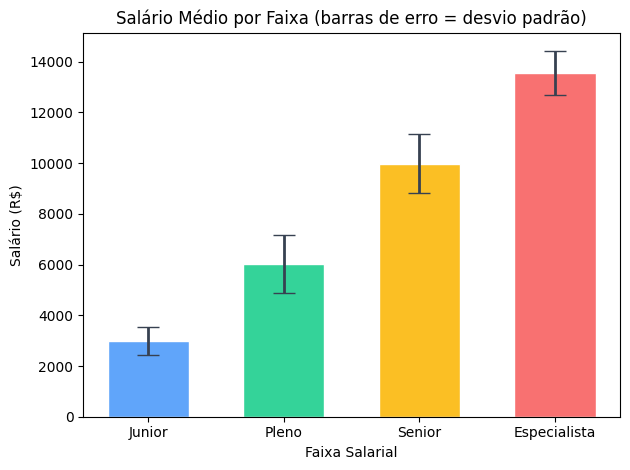

In [35]:
print(f"{'Faixa':14s} {'N':>5} {'Média':>12} {'Mediana':>12} {'Desvio':>10} {'Mín':>10} {'Máx':>10}")
print("─" * 75)

stats_por_faixa = {}
for faixa in ordem:
    mask  = faixa_np == faixa
    sub   = salarios[mask]
    stats_por_faixa[faixa] = {
        "n"      : sub.size,
        "media"  : np.mean(sub),
        "mediana": np.median(sub),
        "std"    : np.std(sub),
        "min"    : np.min(sub),
        "max"    : np.max(sub),
    }
    s = stats_por_faixa[faixa]
    print(f"{faixa:14s} {s['n']:>5d} "
          f"R$ {s['media']:>9,.0f} "
          f"R$ {s['mediana']:>9,.0f} "
          f"R$ {s['std']:>7,.0f} "
          f"R$ {s['min']:>7,.0f} "
          f"R$ {s['max']:>7,.0f}")

# ── Gráfico: média e desvio padrão por faixa (barras com barras de erro) ──
medias  = np.array([stats_por_faixa[f]["media"] for f in ordem])
desvios = np.array([stats_por_faixa[f]["std"]   for f in ordem])

plt.bar(ordem, medias, yerr=desvios, color=cores, edgecolor="white",
        capsize=8, width=0.6, error_kw={"linewidth": 2, "ecolor": "#374151"})
plt.title("Salário Médio por Faixa (barras de erro = desvio padrão)")
plt.xlabel("Faixa Salarial")
plt.ylabel("Salário (R$)")
plt.tight_layout()
plt.show()

---
### O que este gráfico mostra?

As barras mostram o **salário médio** de cada faixa. As barras de erro (linhas pretas em cima de cada barra) representam **1 desvio padrão** acima e abaixo da média — ou seja, onde estão a maioria dos salários de cada faixa.

### Por que isso importa?

- Uma barra de erro curta indica que os salários da faixa são **homogêneos** — todos ganham valores próximos à média
- Uma barra de erro longa indica **grande variação** — pode haver injustiça salarial ou diferenças legítimas por senioridade dentro da faixa
- Esse gráfico só é possível porque usamos `np.std()` — que calcula o desvio padrão vetorizado em milissegundos para qualquer tamanho de base

---
## Exercício Prático — Aula 03

Use **NumPy puro** (sem `.groupby()`, sem `.value_counts()` do pandas) para responder as perguntas abaixo sobre a `base_rh`.

### Passos

1. Extraia como arrays NumPy as colunas `Salario` e `Idade`. Mostre `shape`, `dtype`, `min()` e `max()` de cada um.

2. Calcule **sem loop**: média, mediana, desvio padrão e soma total dos salários. Compare com os valores do `df.describe()` — devem ser iguais.

3. Slicing: selecione os 10 maiores salários usando `np.argsort()`. Exiba os valores.

4. Use `np.where()` para criar o array `geração`:
   - `"Boomer"` se Idade >= 60
   - `"Gen X"` se Idade >= 44
   - `"Millennial"` se Idade >= 28
   - `"Gen Z"` se Idade < 28
   *(Use `np.select()` com as quatro condições.)*

5. Use máscara booleana (sem groupby) para calcular o salário médio de cada geração.

6. Broadcasting: crie o array `salario_normalizado` subtraindo a média e dividindo pelo desvio padrão (padronização z-score). Verifique que a média resultante é ~0 e o desvio é ~1.

7. Gráfico 1 — histograma dos salários com `bins = np.linspace(salarios.min(), salarios.max(), 12)`.

8. Gráfico 2 — barras horizontais com o salário médio de cada geração calculado no passo 5.